# Step 12 — consensus clustering, federated

**Data type: RNA_array** (GSE65391). **Reads:** `step11_site_{A,B,C}.rds`, `step11_features.rds`.
**Writes:** `step12_consensus.rds`, `step12_site_{A,B,C}.rds`, `figures/fig12_RNA_array_consensus_cdf.png`.

An **endotype** is a group of patients who share a pattern of gene expression. We look for such groups
without telling the method anything about disease activity, nephritis or interferon.

**Consensus clustering** (Monti et al. 2003) asks whether groups are stable. For k = 2 to 6 it runs
k-means 100 times, each time on a random 80% of the patients, and records how often each pair of
patients lands in the same cluster. A clean partition puts every pair near "always together" or
"never together". **PAC**, the proportion of ambiguous clustering (Şenbabaoğlu et al. 2014), is the
share of pairs in between (consensus from 0.1 to 0.9). Lower is better.

**Federated, piece by piece:**

| piece | how |
|---|---|
| the 80% subsample | drawn within each site, from its own patients |
| k-means | Lloyd's algorithm, federated: the coordinator sends k centroids; each site assigns its patients and returns a count and a sum per cluster; the coordinator averages. Five random starts, drawn from the pooled spread of each component; the start with the smallest total within-cluster sum of squares wins (each site reports one number). |
| co-clustering counts | each site keeps them for its own pairs of patients. Pairs across sites are never observed, and no site learns another's labels. |
| PAC | each site sends a histogram of its consensus values (100 bins); the coordinator adds them |

The choice of k is the lowest pooled PAC; on a tie (within 0.005), the larger k.

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
start_log("12")
f <- readRDS(art("step11_features.rds"))
P <- lapply(setNames(SITES, SITES), function(s) readRDS(site_file("11", s))$scores)
sapply(P, dim)

A,B,C
37,37,36
10,10,10


In [2]:
set.seed(SEED + 12L)
KS <- 2:6
runs <- lapply(setNames(KS, KS), function(k)
  federated_consensus(P, k, mean = rep(0, ncol(P[[1]])), sd = f$sdev, n_resamples = 100))

In [3]:
pooled_hist <- lapply(runs, function(r) Reduce(`+`, r$histogram))
pac_table <- data.frame(k = KS,
  pac   = sapply(pooled_hist, pac_from_hist),
  pac_A = sapply(runs, function(r) pac_from_hist(r$histogram$A)),
  pac_B = sapply(runs, function(r) pac_from_hist(r$histogram$B)),
  pac_C = sapply(runs, function(r) pac_from_hist(r$histogram$C)))
K <- choose_k(pac_table[, c("k", "pac")])
pac_table$selected <- pac_table$k == K
format(pac_table, digits = 3)

,k,pac,pac_A,pac_B,pac_C,selected
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
2,2,0.155,0.104,0.251,0.108,TRUE
3,3,0.387,0.359,0.354,0.452,FALSE
4,4,0.401,0.345,0.447,0.410,FALSE
5,5,0.406,0.366,0.443,0.410,FALSE
6,6,0.369,0.329,0.395,0.383,FALSE


## Reading PAC

The cumulative distribution of consensus values, from the pooled histograms. A clean partition gives
a curve that is flat between 0.1 and 0.9. PAC is how far the curve rises across that band.

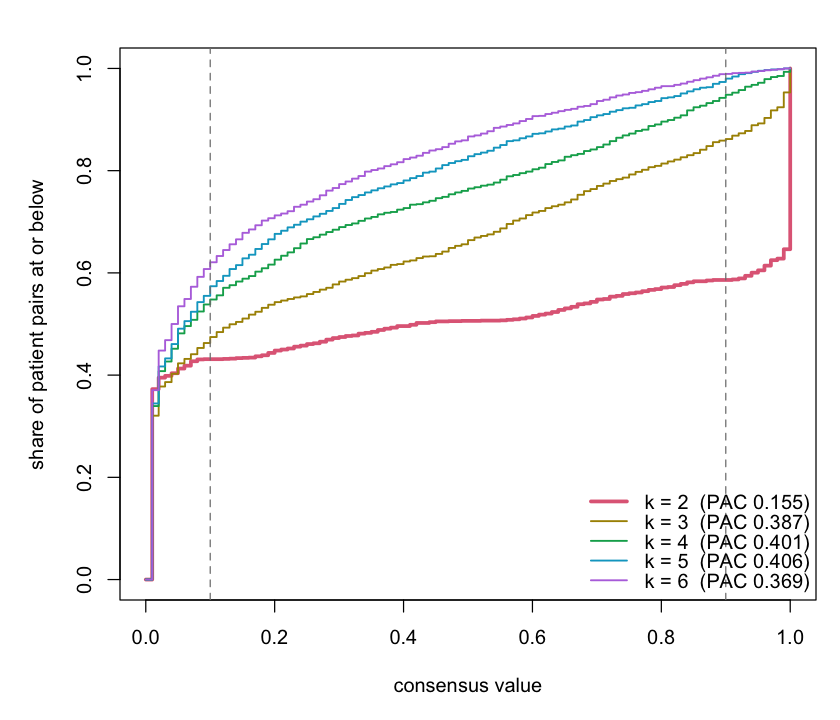

In [4]:
draw_cdf <- function() {
  par(mar = c(5, 5, 2, 1))
  cols <- hcl.colors(length(KS), "Dark 3")
  plot(NULL, xlim = c(0, 1), ylim = c(0, 1), xlab = "consensus value",
       ylab = "share of patient pairs at or below")
  for (i in seq_along(KS)) {
    h <- pooled_hist[[i]]
    lines(BINS, c(0, cumsum(h) / sum(h)), col = cols[i], lwd = if (KS[i] == K) 3 else 1.5, type = "s")
  }
  abline(v = c(0.1, 0.9), lty = 2, col = "grey50")
  legend("bottomright", sprintf("k = %d  (PAC %.3f)", KS, pac_table$pac),
         col = cols, lwd = ifelse(KS == K, 3, 1.5), bty = "n")
}
png(fig("fig12_RNA_array_consensus_cdf.png"), width = 1200, height = 1000, res = 150); draw_cdf(); invisible(dev.off())
options(repr.plot.width = 7, repr.plot.height = 6); draw_cdf()

In [5]:
for (s in SITES)                                   # each site keeps its own consensus matrices
  saveRDS(lapply(runs, function(r) r$consensus[[s]]), site_file("12", s))
saveRDS(list(pac = pac_table, k = K, histograms = pooled_hist), art("step12_consensus.rds"))
cat("wrote", art("step12_consensus.rds"), "\n")

wrote /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/endotypes-transcriptomics/data/run_artifacts/step12_consensus.rds 


## Findings

k = 2 is chosen: pooled PAC 0.155, against 0.37 or more for every larger k. Each site sees the same
thing on its own pairs (PAC 0.10–0.25 at k = 2, 0.33 or more above). Round 1, which pooled all
patients, also chose k = 2 (PAC 0.186). Federation changes where the computation happens, not what
it finds.